# Differentiate a simulation

This tutorial computes the derivative of a simulation output with respect to
a physical parameter, then proves the derivative is correct with finite
differences. The pattern extends to any smooth objective: sensitivity
studies, parameter inference, and inverse design all start here.

The committed outputs below ran on a laptop CPU in under ten seconds total.
Every cell is plain Python. Rerun the notebook after any solver change.

## Why float64

Gradient checks compare two nearly equal numbers, so float32 noise at the
seventh digit destroys the comparison. Enable float64 before any JAX
operation runs.

In [1]:
import math

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from mhx.equations.reduced_mhd import reduced_mhd_rhs_spectral, to_spectral_state
from mhx.grids import CartesianGrid
from mhx.physics import CosineTearingEquilibrium
from mhx.state import ReducedMHDParams
from mhx.time_integrators import evolve_rk4

## A loss function over a solve

The objective is the final spectral magnetic-energy proxy
$L(\eta) = \sum_{\mathbf{k}} |\hat\psi_{\mathbf{k}}(t_f)|^2$
after a 20-step RK4 solve of the
[reduced-MHD equations](../physics/reduced_mhd.md) from the smooth cosine
equilibrium. Everything inside `loss` is a pure function of the resistivity,
so `jax.value_and_grad` differentiates through the whole solve, spectral
operators and time loop included.

In [2]:
grid = CartesianGrid(
    shape=(32, 32),
    lower=(0.0, 0.0),
    upper=(2.0 * math.pi, 2.0 * math.pi),
)
state0 = to_spectral_state(CosineTearingEquilibrium().initial_state(grid))


def loss(resistivity):
    params = ReducedMHDParams(resistivity=resistivity, viscosity=5.0e-3)

    def rhs(state):
        return reduced_mhd_rhs_spectral(state, params, lengths=grid.lengths)

    trajectory = evolve_rk4(state0, rhs, dt=2.0e-2, steps=20, save_every=20)
    return jnp.sum(jnp.abs(trajectory.states.psi[-1]) ** 2)


eta = jnp.asarray(5.0e-3)
value, gradient = jax.value_and_grad(loss)(eta)
print(f"loss     = {value:.10e}")
print(f"gradient = {gradient:.10e}")

loss     = 5.2219529678e+05
gradient = -4.1775644492e+05


The gradient is negative: more resistivity dissipates more magnetic energy.

## Prove it with finite differences

A derivative you have not checked is a guess. Compare against central
differences at several step sizes. The relative error should sit near
machine precision for a smooth objective, and it should be stable when the
step size changes by a decade.

In [3]:
for epsilon in (1.0e-4, 1.0e-5, 1.0e-6):
    finite_difference = (loss(eta + epsilon) - loss(eta - epsilon)) / (2.0 * epsilon)
    relative_error = abs(finite_difference - gradient) / abs(gradient)
    print(
        f"eps={epsilon:.0e}  central={finite_difference:.10e}  "
        f"relative error={relative_error:.2e}"
    )

eps=1e-04  central=-4.1775644537e+05  relative error=1.07e-09


eps=1e-05  central=-4.1775644491e+05  relative error=3.73e-11


eps=1e-06  central=-4.1775644498e+05  relative error=1.37e-10


Relative errors near $10^{-10}$ confirm the derivative. Under float32 the
same comparison shows percent-level disagreement, which is why the
[gradient checklist](../physics/differentiability.md#validate-every-gradient)
makes float64 mandatory.

## See the sensitivity

The gradient is the slope of the loss curve. A small resistivity scan makes
that visible, with the tangent line from `value_and_grad` drawn through the
evaluation point.

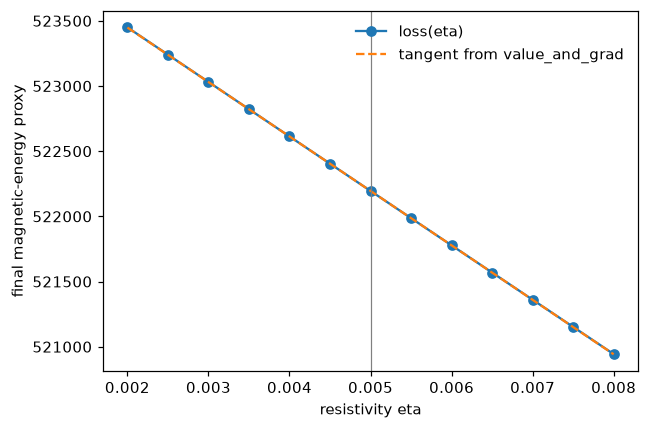

In [4]:
import matplotlib.pyplot as plt
import numpy as np

etas = np.linspace(2.0e-3, 8.0e-3, 13)
losses = [float(loss(jnp.asarray(e))) for e in etas]

figure, axis = plt.subplots(figsize=(6, 4), dpi=110)
axis.plot(etas, losses, marker="o", label="loss(eta)")
tangent = float(value) + float(gradient) * (etas - float(eta))
axis.plot(etas, tangent, linestyle="--", label="tangent from value_and_grad")
axis.axvline(float(eta), color="gray", linewidth=0.8)
axis.set_xlabel("resistivity eta")
axis.set_ylabel("final magnetic-energy proxy")
axis.legend(frameon=False)
figure.tight_layout()

## Where to go next

- Wrap `loss` in an optimizer to fit a parameter to a target trajectory.
  The `research` extra installs Optax for this.
- Differentiate with respect to the initial state instead: pass `state0`
  as the argument and JAX returns a field-shaped gradient.
- Read [what does not differentiate](../physics/differentiability.md#what-does-not-differentiate)
  before optimizing anything built on critical-point counts.
- The script form of this tutorial is
  [`examples/gallery/08_gradient.py`](https://github.com/uwplasma/MHX/blob/main/examples/gallery/08_gradient.py).